# Инвестиционный анализ рынка стартапов и оценка перспективных сегментов

**Автор:** Екатерина Штрейс  
**Период данных:** до 2014 года  
**Горизонт рекомендации:** 2015 год

## Цель исследования

Выявить закономерности финансирования стартапов, сравнить рыночные сегменты и типы капитала, оценить динамику инвестиционной активности и сформировать рекомендацию по наиболее перспективному направлению для вложений.

Анализ опирается на исторические сведения о компаниях, раундах финансирования и возвратах средств. Результаты интерпретируются в контексте инвестиционного решения на начало 2015 года.

## 1. Данные

Основной набор `cb_investments.csv` содержит сведения о компаниях, географии, рыночных сегментах, статусах, датах и объёмах финансирования, количестве раундов и структуре привлечённого капитала.

Дополнительный набор `cb_returns.csv` содержит годовые суммы возвратов по типам финансирования за период с 2000 по 2014 год.

Ключевые показатели исследования: общий объём финансирования, число раундов, длительность привлечения капитала, основной сегмент рынка и суммы по отдельным типам финансирования.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from phik import phik_matrix

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_investments.zip", sep=";", low_memory=False
)

In [4]:
cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [5]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Основной набор содержит сведения о компаниях и проведённых раундах финансирования. В исходных данных присутствуют пропуски и полностью пустые строки; отдельные числовые поля сохранены как текст и требуют очистки.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

В основном наборе 54 294 строки и 40 столбцов. Поле `funding_total_usd` необходимо очистить от разделителей разрядов и преобразовать в числовой формат. Поля с датами финансирования требуют приведения к `datetime`. Пропуски оцениваются с учётом аналитической значимости каждого признака.

In [7]:
display(cb_returns)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


Дополнительная таблица содержит годовые возвраты по типам финансирования за 2000–2014 годы. Структура данных соответствует описанию; явные дубликаты и пропуски отсутствуют.

In [8]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Таблица возвратов содержит 15 наблюдений и 14 столбцов. Типы данных подходят для дальнейших расчётов.

### Результаты первичного обзора

Основной набор требует очистки названий столбцов, преобразования `funding_total_usd`, обработки временных признаков и удаления записей без информации о финансировании. Дополнительная таблица возвратов готова к анализу после установки года в качестве индекса.

## 2. Предобработка данных

In [9]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy()
len(temp)

54294

### 2.1. Нормализация названий столбцов

In [10]:
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [11]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.columns

In [12]:
# Найти столбцы, содержащие пробелы
columns_with_spaces = [col for col in df.columns if " " in col]
if columns_with_spaces:
    print(f"Столбцы с пробелами: {columns_with_spaces}")
else:
    print("Нет столбцов с пробелами")

Нет столбцов с пробелами


### 2.2. Преобразование общего объёма финансирования

In [13]:
display(df["funding_total_usd"])

0         9,00,00,000 
1           20,00,000 
2           90,00,000 
3           77,00,000 
4            5,40,000 
             ...      
54289              NaN
54290              NaN
54291              NaN
54292              NaN
54293              NaN
Name: funding_total_usd, Length: 54294, dtype: object

In [14]:
df['funding_total_usd'] = (
    df['funding_total_usd']
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'],
    errors='coerce'
)

In [15]:
df['funding_total_usd'].head()

0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: float64

### 2.3. Преобразование временных признаков

In [16]:
columns_to_convert = ["first_funding_at", "last_funding_at", "mid_funding_at"]
df[columns_to_convert].head(10)

,first_funding_at,last_funding_at,mid_funding_at
0,2014-01-06,2014-01-06,NaN
1,2014-05-15,2014-05-15,NaN
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2014-11-03,2013-11-21
4,2014-01-14,2014-01-14,NaN
5,2014-10-23,2014-10-23,NaN
6,2013-09-05,2013-12-22,2013-09-05
7,2014-01-12,2014-01-12,NaN
8,2014-09-30,2014-09-30,NaN
9,2007-10-01,2008-03-01,2007-10-01


In [17]:
for col in columns_to_convert:
    # Автоматическое определение
    df[col] = pd.to_datetime(df[col], infer_datetime_format=True, errors="coerce")

    # Проверим, сколько преобразовалось
    success = df[col].notna().sum()
    total = len(df[col])
    print(f"{col}: преобразовано {success} из {total} ({success/total*100:.1f}%)")

first_funding_at: преобразовано 49428 из 54294 (91.0%)
last_funding_at: преобразовано 49432 из 54294 (91.0%)
mid_funding_at: преобразовано 30288 из 54294 (55.8%)


In [18]:
df[columns_to_convert].head(10)

,first_funding_at,last_funding_at,mid_funding_at
0,2014-01-06,2014-01-06,NaT
1,2014-05-15,2014-05-15,NaT
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2014-11-03,2013-11-21
4,2014-01-14,2014-01-14,NaT
5,2014-10-23,2014-10-23,NaT
6,2013-09-05,2013-12-22,2013-09-05
7,2014-01-12,2014-01-12,NaT
8,2014-09-30,2014-09-30,NaT
9,2007-10-01,2008-03-01,2007-10-01


### 2.4. Подготовка таблицы возвратов

In [19]:
cb_returns.set_index("year", inplace=False)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


### 2.5. Обработка текстовых признаков

In [20]:
df.select_dtypes(include='object').head()

,name,homepage_url,category_list,market,status,country_code,state_code,region,city,founded_at,founded_month,founded_quarter
0,Harvard University,http://harvard.edu,|Education|,Education,operating,USA,MA,Boston,Cambridge,1636-09-08,NaN,NaN
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,operating,NaN,NaN,NaN,NaN,1785-01-01,NaN,NaN
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,operating,USA,DE,"Wilmington, Delaware",Wilmington,1802-07-19,NaN,NaN
3,University of Michigan,http://www.umich.edu/,|Education|,Education,operating,USA,MI,Detroit,Ann Arbor,1817-01-01,NaN,NaN
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,operating,USA,OH,Cleveland,Cleveland,1826-01-01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Шаг 1: Очистка названий сегментов
def clean_market_name(name):
    if pd.isna(name):
        return name
    # Убираем лишние пробелы в начале и конце, приводим к нижнему регистру
    cleaned = str(name).strip().lower()
    return cleaned


# Создаем временную очищенную колонку
df["market"] = df["market"].apply(clean_market_name)

In [22]:
# Проверим количество уникальных значений должно быть 49437 не нулевых значений
print("\nКоличество уникальных значений в name:", df["name"].nunique())


Количество уникальных значений в name: 49350


### 2.6. Дубликаты и записи без данных о финансировании

In [23]:
df = df.drop_duplicates().copy()
print('Количество строк после удаления полных дубликатов:', len(df))

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49434,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,mining technologies,9000000.0,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49435,DigiByte,http://digibyte.co,NaN,NaN,250000.0,operating,USA,CA,Los Angeles,Santa Monica,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49436,Xeltis,http://xeltis.com,NaN,NaN,34000000.0,operating,CHE,NaN,Zurich,Zürich,...,0.0,0.0,0.0,34000000.0,0.0,0.0,0.0,0.0,0.0,0.0
49437,Logovers,http://www.logovers.com/,|Incubators|Designers|Entrepreneur|Startups|,startups,11500.0,operating,MEX,NaN,MEX - Other,Hermosillo,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df = df.dropna(how='all').copy()
print('Количество строк после удаления полностью пустых записей:', len(df))

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49433,RiverSilica,http://riversilica.com,NaN,NaN,1500000.0,operating,IND,NaN,Bangalore,Bangalore,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49434,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,mining technologies,9000000.0,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49435,DigiByte,http://digibyte.co,NaN,NaN,250000.0,operating,USA,CA,Los Angeles,Santa Monica,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49436,Xeltis,http://xeltis.com,NaN,NaN,34000000.0,operating,CHE,NaN,Zurich,Zürich,...,0.0,0.0,0.0,34000000.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
df.dropna(subset=["funding_total_usd"], how="all", inplace=True)

### 2.7. Восстановление промежуточной даты финансирования

Пропуски в `mid_funding_at` восстанавливаются как середина интервала между первым и последним раундами при наличии обеих дат.

In [26]:
mask_first = (
    (df["first_funding_at"].isna())
    & (df["mid_funding_at"].notna())
    & (df["last_funding_at"].notna())
)
df.loc[mask_first, "first_funding_at"] = df["mid_funding_at"] - (
    df["last_funding_at"] - df["mid_funding_at"]
)

In [27]:
# Заполняем пропуски
mask = (
    (df["mid_funding_at"].isna())
    & (df["first_funding_at"].notna())
    & (df["last_funding_at"].notna())
)
df.loc[mask, "mid_funding_at"] = (
    df["first_funding_at"] + (df["last_funding_at"] - df["first_funding_at"]) / 2
)

# Оценка оставшихся пропусков
remaining_missing = df["mid_funding_at"].isna().sum()
print(
    f"Осталось пропусков в mid_funding_at: {remaining_missing} ({remaining_missing/len(df)*100:.2f}%)"
)

Осталось пропусков в mid_funding_at: 1 (0.00%)


In [28]:
# Найти строку, где mid_funding_at пустой
missing_row = df[df["mid_funding_at"].isna()]
display(missing_row)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
33041,Nubank,https://www.nubank.com.br/,|Consumer Internet|Financial Services|,financial services,16300000.0,operating,BRA,NaN,Sao Paulo,São Paulo,...,0.0,0.0,14300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


После восстановления временных признаков в `mid_funding_at` остаётся одна запись без значения.

In [29]:
# Проверим сколько удалено строк датасета
print(
    " Было строк в исходном датасете",
    len(temp),
    "\n",
    "Осталось строк в датасете после обработки",
    len(df),
    "\n",
    "Удалено строк в датасете после обработки",
    len(temp) - len(df),
    "\n",
    "Процент потерь",
    round((len(temp) - len(df)) / len(temp) * 100, 2),
)

 Было строк в исходном датасете 54294 
 Осталось строк в датасете после обработки 40907 
 Удалено строк в датасете после обработки 13387 
 Процент потерь 24.66


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                38404 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32201 non-null  object        
 13  founded_month   

In [31]:
# Пропуски по столбцам в относительных значениях
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent_sorted = missing_percent.sort_values(ascending=False)

# Оставим только столбцы с пропусками > 0
missing_with_data = missing_percent_sorted[missing_percent_sorted > 0]

print("Процент пропусков:")
if len(missing_with_data) > 0:
    print(missing_with_data.round(3))

Процент пропусков:
state_code          37.373
participants        33.187
founded_month       21.444
founded_quarter     21.444
founded_year        21.282
founded_at          21.282
city                11.013
country_code         9.336
region               9.336
category_list        6.119
market               6.119
homepage_url         5.657
status               2.701
mid_funding_at       0.002
first_funding_at     0.002
name                 0.002
dtype: float64


### Результаты предобработки

Из выборки удалены полностью пустые записи и компании без данных об общем объёме финансирования. Потеря составила 24,66% исходных строк. Поле `funding_total_usd` преобразовано в числовой формат, временные признаки приведены к `datetime`, а часть пропусков в датах восстановлена на основе доступных границ интервала.

Пропуски в географических, категориальных и справочных полях сохранены, поскольку их искусственное заполнение могло бы исказить структуру рынка. Для ключевых финансовых расчётов используются записи с доступными значениями целевых показателей.

## 3. Инжиниринг признаков

### 3.1. Классификация компаний по длительности финансирования

Компании разделены на три группы: единственный раунд, период финансирования до одного года и период более одного года. Для групп сравниваются доля компаний и доля привлечённого капитала.

In [32]:
# Создаем колонку с количеством дней между первым и последним раундом
df["funding_interval_days"] = (df["last_funding_at"] - df["first_funding_at"]).dt.days


# Функция для распределения по группам (уточненная версия)
def categorize_funding_duration(row):
    if row["funding_rounds"] == 1:
        return "Единичное финансирование"
    elif row["funding_interval_days"] <= 365:
        return "Срок финансирования до года"
    else:
        return "Срок финансирования более года"


# Применяем функцию
df["funding_duration_group"] = df.apply(categorize_funding_duration, axis=1)

# Проверяем результат
print("Распределение компаний по группам:")
print(df["funding_duration_group"].value_counts())
print("\nПример данных с новыми колонками:")
display(
    df[
        [
            "name",
            "first_funding_at",
            "last_funding_at",
            "funding_rounds",
            "funding_interval_days",
            "funding_duration_group",
        ]
    ].head(10)
)

Распределение компаний по группам:
Единичное финансирование          24113
Срок финансирования более года    12292
Срок финансирования до года        4502
Name: funding_duration_group, dtype: int64

Пример данных с новыми колонками:


,name,first_funding_at,last_funding_at,funding_rounds,funding_interval_days,funding_duration_group
0,Harvard University,2014-01-06,2014-01-06,1.0,0.0,Единичное финансирование
1,University of New Brunswick,2014-05-15,2014-05-15,1.0,0.0,Единичное финансирование
2,DuPont,2009-07-02,2009-07-02,1.0,0.0,Единичное финансирование
3,University of Michigan,2013-11-21,2014-11-03,3.0,347.0,Срок финансирования до года
4,Case Western Reserve University,2014-01-14,2014-01-14,1.0,0.0,Единичное финансирование
5,Xavier University,2014-10-23,2014-10-23,1.0,0.0,Единичное финансирование
6,Tulane University,2013-09-05,2013-12-22,4.0,108.0,Срок финансирования до года
7,Duke University,2014-01-12,2014-01-12,1.0,0.0,Единичное финансирование
8,"Virginia Commonwealth University, Richmond",2014-09-30,2014-09-30,1.0,0.0,Единичное финансирование
9,WeGame,2007-10-01,2008-03-01,2.0,152.0,Срок финансирования до года


In [33]:
# 1. Расчет для графика "По количеству компаний"
counts = df["funding_duration_group"].value_counts()
# Нормализуем для получения процентов (умножаем на 100 для отображения в %)
percent_counts = (counts / counts.sum()) * 100

# 2. Расчет для графика "По объему инвестиций"
# Группируем по категориям и суммируем инвестиции
funding_by_group = df.groupby("funding_duration_group")["funding_total_usd"].sum()
# Нормализуем для процентов
percent_funding = (funding_by_group / funding_by_group.sum()) * 100

# 3. Задаем единую цветовую палитру
colors = {
    "Единичное финансирование": "#ff9f8c",  # лососевый/коралловый
    "Срок финансирования до года": "#ffdb7c",  # золотистый/желтый
    "Срок финансирования более года": "#8fd6b3",  # бирюзовый/мятный
}
# Получаем список цветов в том порядке, в котором категории идут в данных
# (например, в порядке убывания частоты для первого графика)
order_for_plot = percent_counts.index.tolist()
plot_colors = [colors[cat] for cat in order_for_plot]

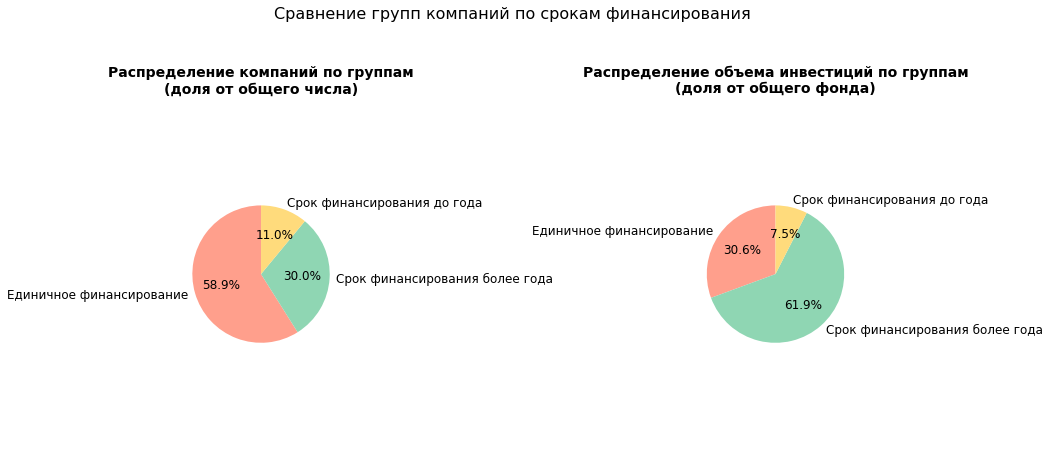

In [34]:
# Создаем фигуру с двумя подграфиками (1 строка, 2 колонки)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- График 1: По количеству компаний (Круговая диаграмма) ---
wedges1, texts1, autotexts1 = ax1.pie(
    percent_counts,
    labels=percent_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[colors[cat] for cat in percent_counts.index],  # Цвета в порядке данных
    textprops={"fontsize": 12},
)
ax1.set_title(
    "Распределение компаний по группам\n(доля от общего числа)",
    fontsize=14,
    fontweight="bold",
)

# --- График 2: По объему инвестиций (Круговая диаграмма) ---
wedges2, texts2, autotexts2 = ax2.pie(
    percent_funding,
    labels=percent_funding.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[colors[cat] for cat in percent_funding.index],  # Цвета в порядке данных
    textprops={"fontsize": 12},
)
ax2.set_title(
    "Распределение объема инвестиций по группам\n(доля от общего фонда)",
    fontsize=14,
    fontweight="bold",
)

# Добавляем общий заголовок
plt.suptitle("Сравнение групп компаний по срокам финансирования", fontsize=16, y=1.05)

# Делаем график более аккуратным (равное соотношение сторон, чтобы круг не был овалом)
ax1.axis("equal")
ax2.axis("equal")

plt.tight_layout()
plt.show()

### Сравнительный анализ групп компаний по срокам финансирования

Сравнивая два графика (распределение компаний и распределение инвестиций), можно сделать следующие ключевые выводы:

---

#### 1. «Долгосрочные» проекты привлекают основные капиталы

Группа **«Срок финансирования более года»** составляет всего **~30%** от общего числа компаний, однако аккумулирует **~60%** всех инвестиций.

Это говорит о том, что инвесторы готовы вкладывать крупные суммы в проекты с длинной историей и, вероятно, с более высоким потенциалом роста. Именно эти компании проходят несколько раундов финансирования и «растят» свои капиталы годами.

---

#### 2. Большинство компаний получают лишь «посевные» инвестиции

Группа **«Единичное финансирование»** составляет большинство **~60%** рынка, но получает лишь треть **~30%** всех денег.

Это классический «пузырь» стартапов: множество мелких проектов, которые либо закрываются после первого раунда, либо не могут привлечь дальнейшее финансирование, либо принципиально не нуждаются в нем (небольшие локальные бизнесы).

---

#### 3. Среднесрочные проекты стабильны

Группа **«Срок финансирования до года»** показывает сбалансированные показатели: доля компаний примерно равна доле привлеченных инвестиций.

Это проекты, которые находят свою нишу, получают финансирование и далее либо быстро растут (переходя в группу «более года»), либо закрываются.

---

Наблюдается действие принципа Парето: меньшинство компаний (30% из группы «Срок более года») привлекают большинство инвестиций (60% от общего объема). Хотя пропорции отличаются от классических 20/80, общая закономерность подтверждается: основная часть капитала концентрируется в небольшой группе проектов с длительным сроком финансирования.

### 3.2. Классификация рыночных сегментов

Сегменты классифицируются по числу представленных компаний. Массовыми считаются сегменты с числом компаний более 120, средними — от 35 до 120, нишевыми — менее 35. Такое укрупнение снижает влияние редких категорий и делает дальнейшие сравнения устойчивее.

In [35]:
# 1. Считаем частоту встречаемости каждого сегмента
market_counts = df["market"].value_counts()

print("Общая статистика по сегментам:")
print(f"Всего уникальных сегментов: {market_counts.nunique()}")
print(f"Диапазон частот: от {market_counts.min()} до {market_counts.max()} компаний")
print("\nТоп-10 самых популярных сегментов:")
print(market_counts.head(10))
print("\n" + "=" * 50 + "\n")


# 2. Создаем функцию для категоризации
def categorize_market(count):
    if count > 120:
        return "массовый"
    elif 35 <= count <= 120:
        return "средний"
    else:  # count < 35
        return "нишевый"


# 3. Применяем категоризацию к каждому сегменту
market_categories = market_counts.map(categorize_market)

# 4. Считаем, сколько сегментов в каждой категории
category_counts = market_categories.value_counts()

# Выводим результат
print("Распределение сегментов по категориям:")
print(category_counts)

# Для наглядности в процентах
category_percents = (category_counts / category_counts.sum() * 100).round(1)
print("\nВ процентах от общего числа сегментов:")
for cat, pct in category_percents.items():
    print(f"{cat}: {pct}%")

Общая статистика по сегментам:
Всего уникальных сегментов: 99
Диапазон частот: от 1 до 4812 компаний

Топ-10 самых популярных сегментов:
software               4812
biotechnology          3590
mobile                 2344
e-commerce             1866
curated web            1693
enterprise software    1381
health care            1185
clean technology       1180
games                  1117
advertising            1107
Name: market, dtype: int64


Распределение сегментов по категориям:
нишевый     289
средний      57
массовый     48
Name: market, dtype: int64

В процентах от общего числа сегментов:
нишевый: 73.4%
средний: 14.5%
массовый: 12.2%


Для дальнейшего анализа массовые сегменты сохраняются отдельно, а средние и нишевые объединяются в агрегированные категории `mid` и `niche`.

In [36]:
# --- Шаг 1. Создаем словарь для замены ---
# Проходим по всем уникальным значениям market и присваиваем им категорию
market_mapping = {}

for market_name in df["market"].unique():
    # Получаем частоту для этого сегмента
    # Если сегмента нет в market_counts (например, NaN), обрабатываем отдельно
    if pd.isna(market_name):
        market_mapping[market_name] = (
            market_name  # оставляем NaN как есть или заменим позже
        )
        continue

    count = market_counts.get(market_name, 0)

    if count > 120:
        # Массовые сегменты оставляем без изменений (их название останется)
        # Важно: мы НЕ заменяем их, поэтому в словаре ставим то же имя
        market_mapping[market_name] = market_name
    elif 35 <= count <= 120:
        market_mapping[market_name] = "mid"
    else:  # count < 35
        market_mapping[market_name] = "niche"

# --- Шаг 2. Применяем замену ---
df["market_aggregated"] = df["market"].map(market_mapping)

# Для наглядности покажем топ-10 массовых сегментов после агрегации
print("\nТоп-10 массовых сегментов (оставлены без изменений):")
print(df["market_aggregated"].value_counts())


Топ-10 массовых сегментов (оставлены без изменений):
software                4812
mid                     3841
biotechnology           3590
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet          

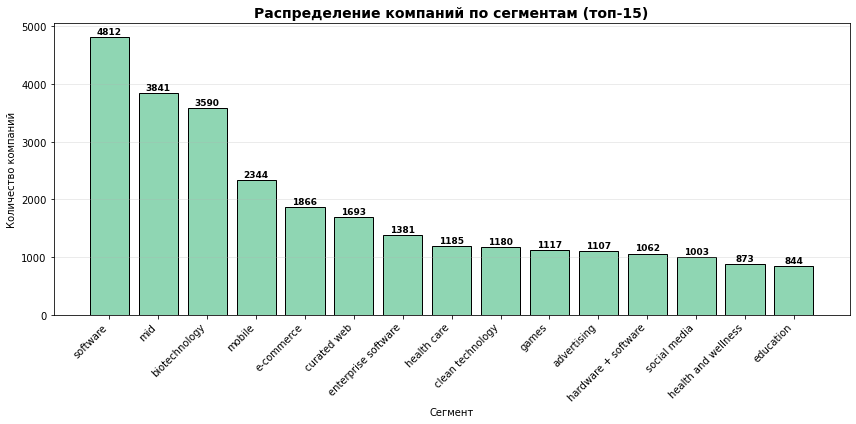

In [37]:
# Получаем распределение после агрегации
distribution = df["market_aggregated"].value_counts()

# Берем топ-15 для наглядности (иначе будет слишком много)
top_15 = distribution.head(15)

plt.figure(figsize=(12, 6))

# Простая столбчатая диаграмма
plt.bar(range(len(top_15)), top_15.values, color="#8fd6b3", edgecolor="black")
plt.xticks(range(len(top_15)), top_15.index, rotation=45, ha="right")
plt.xlabel("Сегмент")
plt.ylabel("Количество компаний")
plt.title(
    "Распределение компаний по сегментам (топ-15)", fontweight="bold", fontsize=14
)

# Добавляем значения на столбцы
for i, v in enumerate(top_15.values):
    plt.text(i, v + 50, str(v), ha="center", fontsize=9, fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Анализ распределений и выбросов

### 4.1. Распределение общего объёма финансирования

Типичный объём привлечённого капитала оценивается по распределению `funding_total_usd`. Финансовые данные ожидаемо имеют выраженный правый хвост, поэтому средние значения дополняются медианой и квартильными характеристиками.

In [38]:
print(f"Описательная статистика:\n{df['funding_total_usd'].describe()}")

Описательная статистика:
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


Лог-нормальное распределение — стандарт для финансовых данных

Правосторонний перекос — ожидаем (мало "единорогов", много мелких)

Медиана $2 млн — типичный раунд Series A

Максимум $30 млрд — реальные цифры для крупнейших компаний

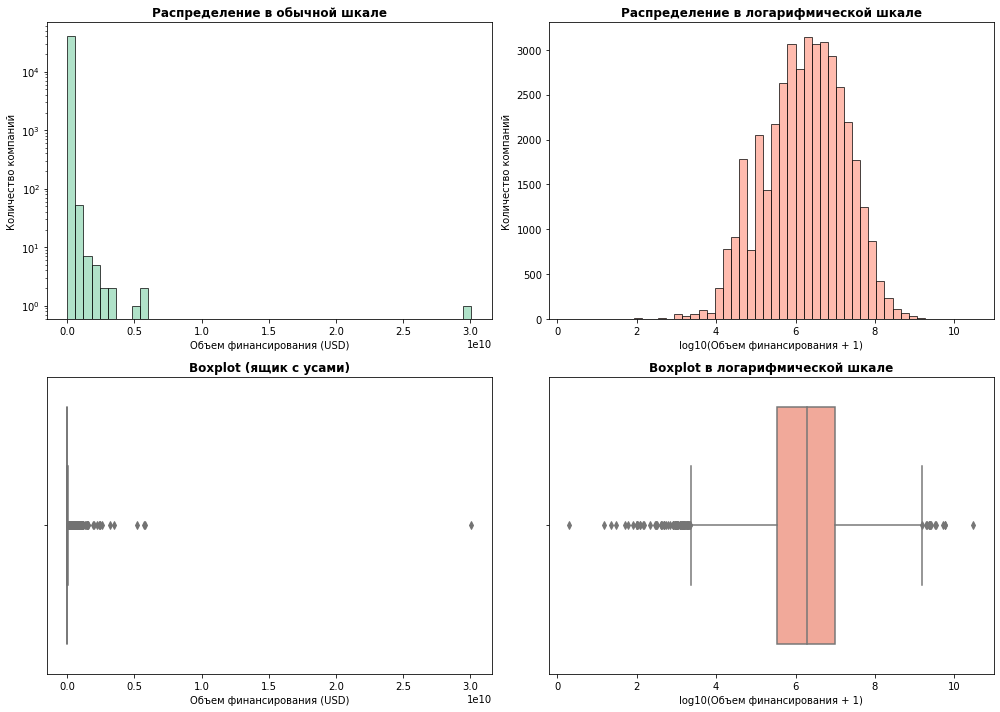

In [39]:
plt.figure(figsize=(14, 10))

# 1. Гистограмма в обычной шкале
plt.subplot(2, 2, 1)
plt.hist(
    df["funding_total_usd"], bins=50, color="#8fd6b3", edgecolor="black", alpha=0.7
)
plt.xlabel("Объем финансирования (USD)")
plt.ylabel("Количество компаний")
plt.title("Распределение в обычной шкале", fontweight="bold")
plt.yscale("log")  # логарифмическая шкала для y, чтобы увидеть хвост

# 2. Гистограмма в логарифмической шкале (x)
plt.subplot(2, 2, 2)
plt.hist(
    np.log10(df["funding_total_usd"] + 1),
    bins=50,
    color="#ff9f8c",
    edgecolor="black",
    alpha=0.7,
)
plt.xlabel("log10(Объем финансирования + 1)")
plt.ylabel("Количество компаний")
plt.title("Распределение в логарифмической шкале", fontweight="bold")

# 3. Boxplot
plt.subplot(2, 2, 3)
sns.boxplot(x=df["funding_total_usd"], color="#ffdb7c")
plt.xlabel("Объем финансирования (USD)")
plt.title("Boxplot (ящик с усами)", fontweight="bold")

# 4. Boxplot в логарифмической шкале
plt.subplot(2, 2, 4)
sns.boxplot(x=np.log10(df["funding_total_usd"] + 1), color="#ff9f8c")
plt.xlabel("log10(Объем финансирования + 1)")
plt.title("Boxplot в логарифмической шкале", fontweight="bold")

plt.tight_layout()
plt.show()

### Выявление аномального финансирования по сегментам

Выбросы определяются методом IQR отдельно внутри каждого агрегированного сегмента. Дополнительно рассчитывается доля компаний с аномальным объёмом финансирования, чтобы выявить категории с наиболее неоднородной структурой капитала.

In [40]:
# 1. Функция для определения выбросов по методу IQR
def identify_outliers_by_iqr(group):
    if len(group) < 4:  # Если группа слишком маленькая, IQR ненадежен
        return pd.Series(False, index=group.index)
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (group < lower_bound) | (group > upper_bound)


# 2. Создаем колонку is_outlier
df["is_outlier"] = df.groupby("market_aggregated")["funding_total_usd"].transform(
    identify_outliers_by_iqr
)

# 3. Заполняем пропуски (NaN) значением False
# Это гарантирует, что все значения будут bool
df["is_outlier"] = df["is_outlier"].fillna(False)

# 4. Создаем чистый датасет БЕЗ выбросов
df_clean = df[~df["is_outlier"]].copy()

# 5. Смотрим на результат
print("=== СТАТИСТИКА ПО ВЫБРОСАМ (до удаления) ===")
print(df["is_outlier"].value_counts())
print(f"Доля выбросов: {df['is_outlier'].sum() / len(df) * 100:.2f}%")

print("\n=== СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ ===")
print(f"Компаний осталось: {len(df_clean)}")
print(f"Удалено компаний: {len(df) - len(df_clean)}")

=== СТАТИСТИКА ПО ВЫБРОСАМ (до удаления) ===
False    36036
True      4871
Name: is_outlier, dtype: int64
Доля выбросов: 11.91%

=== СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ ===
Компаний осталось: 36036
Удалено компаний: 4871


In [41]:
# Работаем с чистым датасетом
df_clean["mid_funding_at"] = pd.to_datetime(df_clean["mid_funding_at"])
df_clean["funding_year"] = df_clean["mid_funding_at"].dt.year

print("Распределение раундов по годам (после удаления выбросов):")
yearly_rounds = df_clean.groupby("funding_year").size().sort_index()
print(yearly_rounds)

Распределение раундов по годам (после удаления выбросов):
funding_year
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       3
1997.0       4
1998.0       9
1999.0      30
2000.0      68
2001.0      43
2002.0      53
2003.0      64
2004.0     101
2005.0     705
2006.0    1180
2007.0    1606
2008.0    1999
2009.0    2657
2010.0    3513
2011.0    4334
2012.0    5563
2013.0    7872
2014.0    6201
dtype: int64


### Вывод

Финансовые данные ожидаемо имеют сильный правый хвост.  
Это значит, что небольшое число компаний привлекает несопоставимо большие суммы по сравнению с остальными.

Для дальнейшего анализа динамики разумно исключить выбросы, чтобы аномально крупные сделки не искажали типичные значения.

### 4.2. Формирование аналитической выборки

Из дальнейшего анализа исключаются компании с аномальным финансированием. Для динамических расчётов используются годы с достаточной инвестиционной активностью — не менее 50 зафиксированных раундов.

In [42]:
# Убедимся, что дата в правильном формате
df_clean["mid_funding_at"] = pd.to_datetime(df_clean["mid_funding_at"])
df_clean["year"] = df_clean["mid_funding_at"].dt.year

# Находим годы с 50+ раундами
yearly_counts = df_clean.groupby("year").size()
active_years = yearly_counts[yearly_counts >= 50].index

# Оставляем только компании из активных годов
# ЭТОТ ДАТАФРЕЙМ МЫ БУДЕМ ИСПОЛЬЗОВАТЬ ДЛЯ ВСЕГО ДАЛЬНЕЙШЕГО АНАЛИЗА
df_final = df_clean[df_clean["year"].isin(active_years)].copy()

print(f"Компаний до фильтрации: {len(df_clean)}")
print(f"Компаний после фильтрации: {len(df_final)}")
print(f"Активные годы: {sorted(active_years)}")

Компаний до фильтрации: 36036
Компаний после фильтрации: 35916
Активные годы: [2000.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


In [43]:
# Фильтруем данные за 2014 год
df_first_funding_2014 = df[df["first_funding_at"].dt.year == 2014]

print("=== ПЕРИОД ПЕРВОГО ФИНАНСИРОВАНИЯ В 2014 ГОДУ ===")
print(
    f"Самая ранняя дата первого финансирования в 2014: {df_first_funding_2014['first_funding_at'].min()}"
)
print(
    f"Самая поздняя дата первого финансирования в 2014: {df_first_funding_2014['first_funding_at'].max()}"
)
print(
    f"Всего компаний, получивших первое финансирование в 2014: {len(df_first_funding_2014)}"
)

=== ПЕРИОД ПЕРВОГО ФИНАНСИРОВАНИЯ В 2014 ГОДУ ===
Самая ранняя дата первого финансирования в 2014: 2014-01-01 00:00:00
Самая поздняя дата первого финансирования в 2014: 2014-12-31 00:00:00
Всего компаний, получивших первое финансирование в 2014: 6477


In [44]:
# Убедимся, что колонка в правильном формате
df["first_funding_at"] = pd.to_datetime(df["first_funding_at"])

# Данные за 2014 год
df_2014 = df[df["first_funding_at"].dt.year == 2014].copy()

print("=== ПРОВЕРКА ПОЛНОТЫ ДАННЫХ ЗА 2014 ГОД ===")
print(f"Всего компаний с первым финансированием в 2014: {len(df_2014)}")

# 1. Проверка по месяцам
df_2014["month"] = df_2014["first_funding_at"].dt.month
monthly_counts = df_2014.groupby("month").size()

print("\n1. РАСПРЕДЕЛЕНИЕ ПО МЕСЯЦАМ:")
for month in range(1, 13):
    count = monthly_counts.get(month, 0)
    status = "✅" if count > 0 else "❌"
    print(f"   Месяц {month:02d}: {count:4d} компаний {status}")

# 2. Проверка по кварталам
df_2014["quarter"] = df_2014["first_funding_at"].dt.quarter
quarterly_counts = df_2014.groupby("quarter").size()

print("\n2. РАСПРЕДЕЛЕНИЕ ПО КВАРТАЛАМ:")
for quarter in range(1, 5):
    count = quarterly_counts.get(quarter, 0)
    print(f"   Квартал {quarter}: {count} компаний")

# 3. Проверка начала и конца года
first_date = df_2014["first_funding_at"].min()
last_date = df_2014["first_funding_at"].max()

print(f"\n3. ГРАНИЦЫ ПЕРИОДА:")
print(f"   Первое финансирование: {first_date}")
print(f"   Последнее финансирование: {last_date}")

# Проверка, покрыт ли весь год
year_start = pd.Timestamp("2014-01-01")
year_end = pd.Timestamp("2014-12-31")

covers_january = first_date <= pd.Timestamp("2014-01-31")
covers_december = last_date >= pd.Timestamp("2014-12-01")

print(f"\n4. ПОКРЫТИЕ ГОДА:")
print(f"   Есть данные за январь: {'✅' if covers_january else '❌'}")
print(f"   Есть данные за декабрь: {'✅' if covers_december else '❌'}")

if covers_january and covers_december:
    print("\n✅ Данные покрывают весь 2014 год (с января по декабрь)!")
else:
    print("\n⚠️ Данные НЕ покрывают весь 2014 год полностью")

=== ПРОВЕРКА ПОЛНОТЫ ДАННЫХ ЗА 2014 ГОД ===
Всего компаний с первым финансированием в 2014: 6477

1. РАСПРЕДЕЛЕНИЕ ПО МЕСЯЦАМ:
   Месяц 01:  810 компаний ✅
   Месяц 02:  635 компаний ✅
   Месяц 03:  661 компаний ✅
   Месяц 04:  593 компаний ✅
   Месяц 05:  549 компаний ✅
   Месяц 06:  669 компаний ✅
   Месяц 07:  671 компаний ✅
   Месяц 08:  525 компаний ✅
   Месяц 09:  538 компаний ✅
   Месяц 10:  492 компаний ✅
   Месяц 11:  311 компаний ✅
   Месяц 12:   23 компаний ✅

2. РАСПРЕДЕЛЕНИЕ ПО КВАРТАЛАМ:
   Квартал 1: 2106 компаний
   Квартал 2: 1811 компаний
   Квартал 3: 1734 компаний
   Квартал 4: 826 компаний

3. ГРАНИЦЫ ПЕРИОДА:
   Первое финансирование: 2014-01-01 00:00:00
   Последнее финансирование: 2014-12-31 00:00:00

4. ПОКРЫТИЕ ГОДА:
   Есть данные за январь: ✅
   Есть данные за декабрь: ✅

✅ Данные покрывают весь 2014 год (с января по декабрь)!


In [45]:
# Сначала проверим тип данных и уникальные значения
print("Тип данных колонки is_outlier:", df["is_outlier"].dtype)
print("\nУникальные значения в is_outlier:")
print(df["is_outlier"].value_counts(dropna=False))
print(f"\nПропусков (NaN): {df['is_outlier'].isna().sum()}")

Тип данных колонки is_outlier: bool

Уникальные значения в is_outlier:
False    36036
True      4871
Name: is_outlier, dtype: int64

Пропусков (NaN): 0


In [46]:
# NaN, сначала заполним их
df["is_outlier"] = df["is_outlier"].fillna(False).astype(bool)

# Проверим после исправления
print("\nПосле исправления:")
print(f"Тип данных: {df['is_outlier'].dtype}")
print(df["is_outlier"].value_counts())


После исправления:
Тип данных: bool
False    36036
True      4871
Name: is_outlier, dtype: int64


In [47]:
# Проверим, сколько у нас выбросов
total_outliers = df["is_outlier"].sum()
total_companies = len(df)

print("=== СТАТИСТИКА ДО УДАЛЕНИЯ ===")
print(f"Всего компаний в датасете: {total_companies}")
print(
    f"Компаний с аномальным финансированием: {total_outliers} ({total_outliers/total_companies*100:.2f}%)"
)
print(
    f"Компаний с нормальным финансированием: {total_companies - total_outliers} ({(total_companies - total_outliers)/total_companies*100:.2f}%)"
)

# Создаем новый датасет без выбросов
df_clean = df[~df["is_outlier"]].copy()

print("\n=== СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ ===")
print(f"Компаний осталось: {len(df_clean)}")
print(f"Удалено компаний: {total_companies - len(df_clean)}")

=== СТАТИСТИКА ДО УДАЛЕНИЯ ===
Всего компаний в датасете: 40907
Компаний с аномальным финансированием: 4871 (11.91%)
Компаний с нормальным финансированием: 36036 (88.09%)

=== СТАТИСТИКА ПОСЛЕ УДАЛЕНИЯ ===
Компаний осталось: 36036
Удалено компаний: 4871


In [48]:
# Убедимся, что mid_funding_at в правильном формате
df_clean["mid_funding_at"] = pd.to_datetime(df_clean["mid_funding_at"])

# Извлекаем год из mid_funding_at
df_clean["funding_year"] = df_clean["mid_funding_at"].dt.year

print("Распределение раундов по годам:")
yearly_rounds = df_clean.groupby("funding_year").size().sort_index()
print(yearly_rounds)

Распределение раундов по годам:
funding_year
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       3
1997.0       4
1998.0       9
1999.0      30
2000.0      68
2001.0      43
2002.0      53
2003.0      64
2004.0     101
2005.0     705
2006.0    1180
2007.0    1606
2008.0    1999
2009.0    2657
2010.0    3513
2011.0    4334
2012.0    5563
2013.0    7872
2014.0    6201
dtype: int64


In [49]:
# Убедимся, что дата в правильном формате
df_clean["mid_funding_at"] = pd.to_datetime(df_clean["mid_funding_at"])
df_clean["year"] = df_clean["mid_funding_at"].dt.year

# Находим годы с 50+ раундами
yearly_counts = df_clean.groupby("year").size()
active_years = yearly_counts[yearly_counts >= 50].index

# Оставляем только компании из активных годов
df_final = df_clean[df_clean["year"].isin(active_years)].copy()

print(f"Компаний до фильтрации: {len(df_clean)}")
print(f"Компаний после фильтрации: {len(df_final)}")
print(f"Активные годы: {list(active_years)}")

Компаний до фильтрации: 36036
Компаний после фильтрации: 35916
Активные годы: [2000.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


### Результат формирования выборки

Дальнейший анализ проводится на данных без экстремальных значений финансирования. Это позволяет описывать типичные рыночные закономерности, не смешивая их с единичными сверхкрупными сделками.

### 4.3. Структура финансирования по объёму и частоте использования

Типы финансирования сравниваются по двум показателям: совокупной привлечённой сумме и количеству компаний, использовавших соответствующий инструмент. Сопоставление позволяет отделить массовые инструменты с небольшим средним чеком от редких, но капиталоёмких форм финансирования.

In [50]:
# Список столбцов с типами финансирования
funding_types = [
    "seed",
    "venture",
    "equity_crowdfunding",
    "undisclosed",
    "convertible_note",
    "debt_financing",
    "angel",
    "grant",
    "private_equity",
    "post_ipo_equity",
    "post_ipo_debt",
    "secondary_market",
    "product_crowdfunding",
]

# Убедимся, что все типы есть в датафрейме
available_types = [col for col in funding_types if col in df_final.columns]
print(f"Доступные типы финансирования: {available_types}")

Доступные типы финансирования: ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


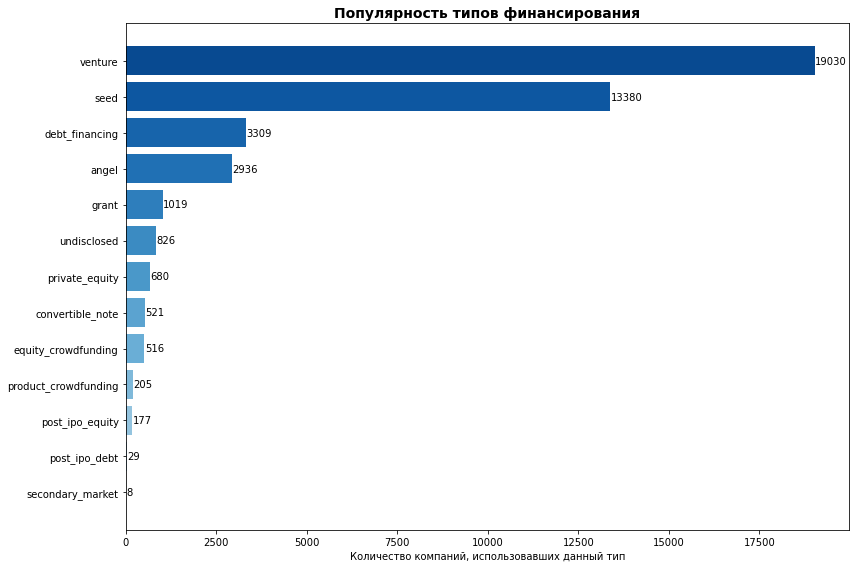

In [51]:
# Считаем, сколько раз каждый тип использовался (значение > 0)
type_popularity = (df_final[available_types] > 0).sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(type_popularity)))
bars = plt.barh(range(len(type_popularity)), type_popularity.values, color=colors)
plt.yticks(range(len(type_popularity)), type_popularity.index)
plt.xlabel("Количество компаний, использовавших данный тип")
plt.title("Популярность типов финансирования", fontweight="bold", fontsize=14)

# Добавляем значения
for i, (bar, val) in enumerate(zip(bars, type_popularity.values)):
    plt.text(
        val + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val)}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

### Вывод

`venture` — безусловный лидер и по объёму, и по частоте использования.  
`seed` используется очень часто, но по объёму сильно уступает `venture`. Это логично, так как seed обычно связан с ранней стадией и меньшими чеками.

Есть и обратная ситуация: `private_equity` и `debt_financing` встречаются заметно реже, но по объёму денег выглядят существенно сильнее многих популярных типов.

In [52]:
# Считаем сумму по каждому типу финансирования
type_sums = df_final[available_types].sum().sort_values(ascending=True)

# Считаем, сколько раз каждый тип использовался (значение > 0)
type_popularity = (df_final[available_types] > 0).sum().sort_values(ascending=True)

print("Суммы по типам финансирования:")
print(type_sums)
print("\nПопулярность типов финансирования:")
print(type_popularity)

Суммы по типам финансирования:
secondary_market        1.240862e+08
product_crowdfunding    1.933103e+08
equity_crowdfunding     2.629606e+08
convertible_note        5.656449e+08
grant                   2.168163e+09
angel                   2.500264e+09
undisclosed             2.877829e+09
post_ipo_debt           4.286718e+09
post_ipo_equity         5.099300e+09
private_equity          9.262413e+09
seed                    9.467729e+09
debt_financing          1.429935e+10
venture                 1.337020e+11
dtype: float64

Популярность типов финансирования:
secondary_market            8
post_ipo_debt              29
post_ipo_equity           177
product_crowdfunding      205
equity_crowdfunding       516
convertible_note          521
private_equity            680
undisclosed               826
grant                    1019
angel                    2936
debt_financing           3309
seed                    13380
venture                 19030
dtype: int64


In [53]:
# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame(
    {
        "Тип финансирования": type_sums.index,
        "Объём (млрд $)": (type_sums.values / 1e9).round(2),
        "Популярность (компаний)": [type_popularity[t] for t in type_sums.index],
        "Средний чек (млн $)": (
            type_sums.values / [type_popularity[t] for t in type_sums.index] / 1e6
        ).round(2),
    }
)

print("=== СРАВНИТЕЛЬНЫЙ АНАЛИЗ ТИПОВ ФИНАНСИРОВАНИЯ ===")
print(comparison_df.to_string(index=False))

# Находим контрастные типы
print("\n" + "=" * 60)
print("ТИПЫ С КОНТРАСТНЫМИ ХАРАКТЕРИСТИКАМИ:")
print("=" * 60)

# Часто используемые, но с малым объёмом
frequent_low = comparison_df[
    (
        comparison_df["Популярность (компаний)"]
        > comparison_df["Популярность (компаний)"].median()
    )
    & (comparison_df["Объём (млрд $)"] < comparison_df["Объём (млрд $)"].median())
]
print("\n🔹 ЧАСТО ИСПОЛЬЗУЕМЫЕ, НО С МАЛЫМ ОБЪЁМОМ:")
for _, row in frequent_low.iterrows():
    print(
        f"  • {row['Тип финансирования']}: {row['Популярность (компаний)']} компаний, но всего {row['Объём (млрд $)']} млрд $"
    )

# Редко используемые, но с большим объёмом
rare_high = comparison_df[
    (
        comparison_df["Популярность (компаний)"]
        < comparison_df["Популярность (компаний)"].median()
    )
    & (comparison_df["Объём (млрд $)"] > comparison_df["Объём (млрд $)"].median())
]
print("\n🔸 РЕДКО ИСПОЛЬЗУЕМЫЕ, НО С БОЛЬШИМ ОБЪЁМОМ:")
for _, row in rare_high.iterrows():
    print(
        f"  • {row['Тип финансирования']}: всего {row['Популярность (компаний)']} компаний, но {row['Объём (млрд $)']} млрд $"
    )

=== СРАВНИТЕЛЬНЫЙ АНАЛИЗ ТИПОВ ФИНАНСИРОВАНИЯ ===
  Тип финансирования  Объём (млрд $)  Популярность (компаний)  Средний чек (млн $)
    secondary_market            0.12                        8                15.51
product_crowdfunding            0.19                      205                 0.94
 equity_crowdfunding            0.26                      516                 0.51
    convertible_note            0.57                      521                 1.09
               grant            2.17                     1019                 2.13
               angel            2.50                     2936                 0.85
         undisclosed            2.88                      826                 3.48
       post_ipo_debt            4.29                       29               147.82
     post_ipo_equity            5.10                      177                28.81
      private_equity            9.26                      680                13.62
                seed            9.47 

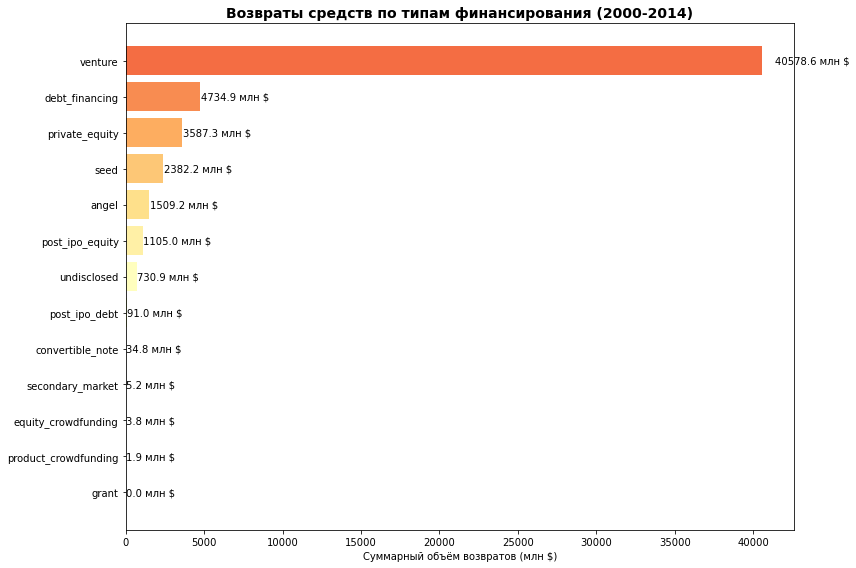

In [54]:
# Используем cb_returns
# Убедимся, что year - индекс
if "year" in cb_returns.columns:
    cb_returns.set_index("year", inplace=True)

# Суммируем возвраты по всем типам за весь период
returns_sums = cb_returns.sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(returns_sums)))
bars = plt.barh(range(len(returns_sums)), returns_sums.values, color=colors)
plt.yticks(range(len(returns_sums)), returns_sums.index)
plt.xlabel("Суммарный объём возвратов (млн $)")
plt.title(
    "Возвраты средств по типам финансирования (2000-2014)",
    fontweight="bold",
    fontsize=14,
)

# Добавляем значения
for i, (bar, val) in enumerate(zip(bars, returns_sums.values)):
    plt.text(
        val * 1.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f} млн $",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

### Совокупные возвраты по типам финансирования

Дополнительная таблица используется для сравнения суммарных возвратов за весь доступный период.

### Вывод

По суммарным возвратам также лидирует `venture`.  
Далее с большим отрывом идут `debt_financing`, `private_equity`, `seed` и `angel`.

Это согласуется с анализом объёмов: крупнейшие по вложениям типы финансирования в целом дают и крупнейшие возвраты.

## 5. Анализ инвестиционной динамики

### 5.1. Динамика активности и типичного размера раунда

Для каждой компании рассчитывается средний объём одного раунда. По годам сравниваются медианный размер раунда, общее количество раундов и число компаний, получивших финансирование. Анализ ограничивается периодом с достаточным количеством наблюдений.

In [55]:
# Средний объём одного раунда
df_final["avg_round_size"] = df_final["funding_total_usd"] / df_final["funding_rounds"]
df_final["year"] = df_final["first_funding_at"].dt.year

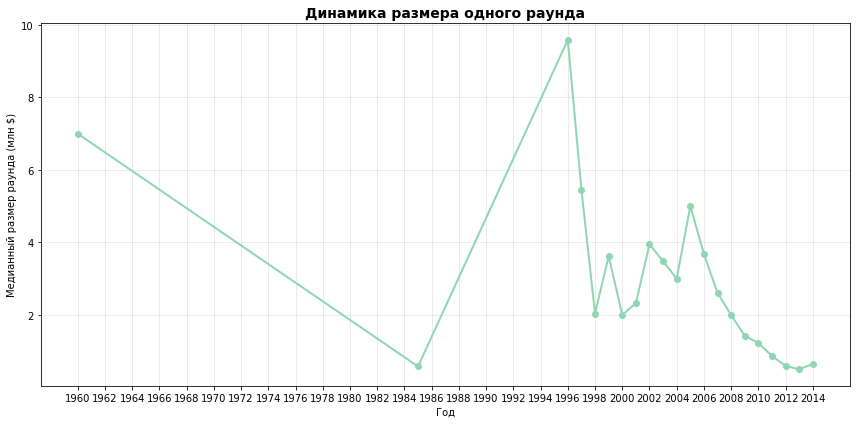

In [56]:
# Средний объём одного раунда
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

df_final["avg_round_size"] = df_final["funding_total_usd"] / df_final["funding_rounds"]
df_final["year"] = df_final["first_funding_at"].dt.year

# Динамика размера раунда
yearly_median = df_final.groupby("year")["avg_round_size"].median().dropna() / 1e6
axes.plot(yearly_median.index, yearly_median.values, "o-", color="#8fd6b3", linewidth=2)
axes.set_xlabel("Год")
axes.set_ylabel("Медианный размер раунда (млн $)")
axes.set_title("Динамика размера одного раунда", fontweight="bold", fontsize=14)
axes.grid(True, alpha=0.3)

# Делаем подписи лет через каждые 2 года
axes.set_xticks(
    range(int(yearly_median.index.min()), int(yearly_median.index.max()) + 1, 2)
)

plt.tight_layout()
plt.show()

Максималный медианнй размер раунда наблюдался в 1996 году, затем резко падал до 1998 и не возвращался.
С 2005 года наблюдается небольшой пик, затем тенденция идет на спад.

Важно отметить, что до 2000 года данных очень мало (единичные раунды).

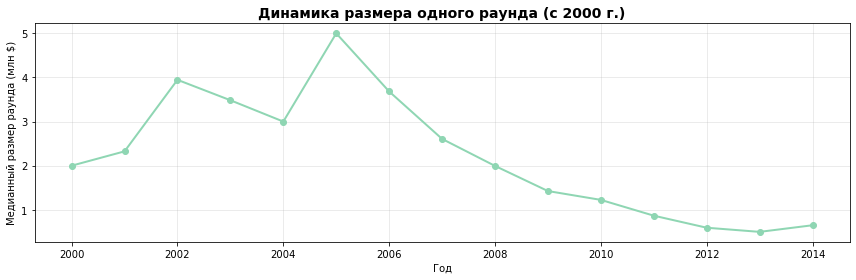

In [57]:
# Средний объём одного раунда (с 2000 года)
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

# Расчет среднего размера раунда
df_final["avg_round_size"] = df_final["funding_total_usd"] / df_final["funding_rounds"]
df_final["year"] = df_final["first_funding_at"].dt.year

# Динамика размера раунда
yearly_median = df_final.groupby("year")["avg_round_size"].median().dropna() / 1e6

# --- Важное изменение: Фильтруем данные с 2000 года ---
yearly_median = yearly_median[yearly_median.index >= 2000]

axes.plot(yearly_median.index, yearly_median.values, "o-", color="#8fd6b3", linewidth=2)
axes.set_xlabel("Год")
axes.set_ylabel("Медианный размер раунда (млн $)")
axes.set_title(
    "Динамика размера одного раунда (с 2000 г.)", fontweight="bold", fontsize=14
)
axes.grid(True, alpha=0.3)

# Делаем подписи лет с 2000 года
axes.set_xticks(range(2000, int(yearly_median.index.max()) + 1, 2))

plt.tight_layout()
plt.show()

При анализе данных с 2000 года, когда количество наблюдений становится статистически значимым, видна четкая картина:

Пик начала 2000-х: Наибольший медианный размер раунда наблюдался в 2005 году, после чего последовало падение до 2013 года и началом роста 2014.


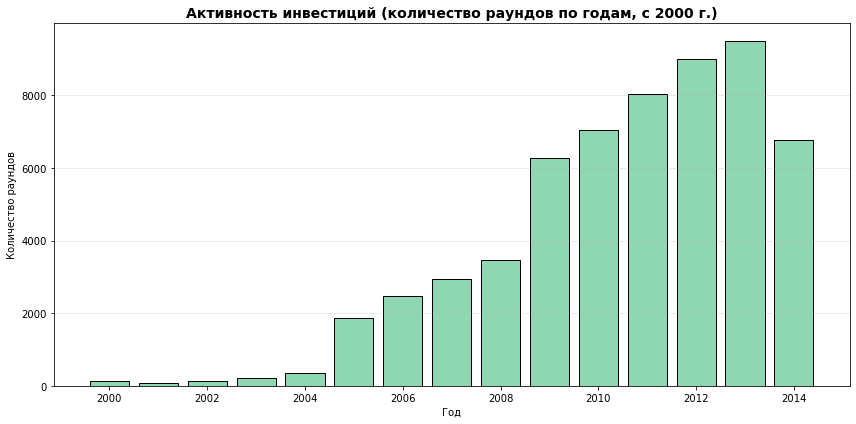

In [58]:
# Количество раундов (с 2000 года)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

yearly_rounds = df_final.groupby("year")["funding_rounds"].sum()

# --- Важное изменение: Фильтруем данные с 2000 года ---
yearly_rounds = yearly_rounds[yearly_rounds.index >= 2000]

ax.bar(yearly_rounds.index, yearly_rounds.values, color="#8fd6b3", edgecolor="black")
ax.set_xlabel("Год")
ax.set_ylabel("Количество раундов")
ax.set_title(
    "Активность инвестиций (количество раундов по годам, с 2000 г.)",
    fontweight="bold",
    fontsize=14,
)
ax.grid(axis="y", alpha=0.3)

# Делаем подписи лет с 2000 года
ax.set_xticks(range(2000, int(yearly_rounds.index.max()) + 1, 2))

plt.tight_layout()
plt.show()

Колличесво раундов начинает расти с 1998 года, несколько резких скачков вверх в 2005 и 2009 годах, в  2013 году наблюдается максимальная активность инвестиций, после чего резкое(но не сильное) падение в 2014 году.

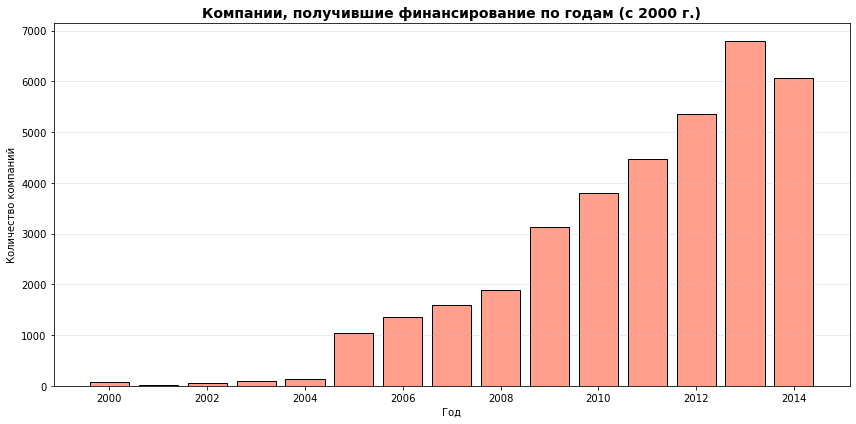

In [59]:
# Количество компаний, получивших финансирование (с 2000 года)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

yearly_companies = df_final.groupby("year").size()

# --- Важное изменение: Фильтруем данные с 2000 года ---
yearly_companies = yearly_companies[yearly_companies.index >= 2000]

ax.bar(
    yearly_companies.index, yearly_companies.values, color="#ff9f8c", edgecolor="black"
)
ax.set_xlabel("Год")
ax.set_ylabel("Количество компаний")
ax.set_title(
    "Компании, получившие финансирование по годам (с 2000 г.)",
    fontweight="bold",
    fontsize=14,
)
ax.grid(axis="y", alpha=0.3)

# Делаем подписи лет с 2000 года
ax.set_xticks(range(2000, int(yearly_companies.index.max()) + 1, 2))

plt.tight_layout()
plt.show()

Динамика роста количества компаний схожа с графиком роста Активности инвестиций, рост с 1998, скачки 2005 и 2009, пик 2013 и некоторое снижение в 2014.

### Вывод по динамике предоставления финансирования по годам

Наблюдается разнонаправленная динамика: количество компаний и раундов активно росло до 2013 года, а затем немного снизилось. При этом средний размер одного раунда, достигнув пика в 2005 году, так и не вернулся к прежним значениям и последние годы демонстрирует тенденцию к снижению. Это говорит о том, что рынок стал более массовым, но менее "крупным" — деньги распределяются между бóльшим числом компаний, но каждый раунд стал меньше.

После 2000х максимум зафиксирован в 2005 году. 

В 2014 году раундов стало чуть меньше, но каждый раунд стал немного крупнее, чем в 2013-м.



### 5.2. Динамика финансирования растущих массовых сегментов

Суммарное финансирование агрегируется по годам и массовым сегментам. В фокусе находятся категории, показавшие рост в 2014 году относительно 2013 года.

In [60]:
# Сводная таблица: суммарное финансирование по годам и сегментам
massive = df_final[~df_final["market_aggregated"].isin(["mid", "niche"])].copy()
pivot = massive.pivot_table(
    values="funding_total_usd",
    index="year",
    columns="market_aggregated",
    aggfunc="sum",
    fill_value=0,
)

# Отбираем сегменты с ростом в 2014 году
if 2013 in pivot.index and 2014 in pivot.index:
    # Сегменты, где сумма в 2014 > суммы в 2013
    growing = pivot.loc[2014] > pivot.loc[2013]
    growing_segments = pivot.loc[2014, growing].index.tolist()

    print(f"Сегменты с ростом в 2014 году: {len(growing_segments)}")
    print("\nДинамика роста (млн $):")
    for seg in growing_segments[:10]:  # топ-10
        val_2013 = pivot.loc[2013, seg] / 1e6
        val_2014 = pivot.loc[2014, seg] / 1e6
        growth = (val_2014 / val_2013 - 1) * 100
        print(f"{seg}: {val_2013:.1f} → {val_2014:.1f} млн $ ({growth:+.1f}%)")
else:
    print("Нет данных за 2013 или 2014 год")
    growing_segments = []

pivot

Сегменты с ростом в 2014 году: 18

Динамика роста (млн $):
apps: 29.9 → 59.4 млн $ (+98.6%)
big data: 42.1 → 77.2 млн $ (+83.6%)
cloud computing: 60.1 → 72.0 млн $ (+19.7%)
entertainment: 33.3 → 60.3 млн $ (+81.4%)
internet: 35.9 → 113.9 млн $ (+217.7%)
manufacturing: 305.7 → 448.3 млн $ (+46.7%)
medical: 69.7 → 167.8 млн $ (+140.8%)
networking: 55.0 → 60.3 млн $ (+9.7%)
news: 47.3 → 61.4 млн $ (+29.9%)
photography: 40.5 → 49.2 млн $ (+21.6%)


market_aggregated,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,semiconductors,social media,social network media,software,sports,startups,technology,travel,video,web hosting
year,,,,,,,,,,,,,,,,,,,,,
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,5600000,0,0,0,0,0,0
1998,0,3671000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1999,6250000,13622803,0,0,0,27070000,33052663,0,4500000,0,...,0,0,0,0,0,0,8500000,0,0,0
2000,25220000,1200000,0,0,0,0,0,11500000,0,1000000,...,0,0,0,36025840,0,0,0,50230,0,95343090
2001,0,14156544,0,0,0,43500000,0,0,0,4650000,...,45200000,0,0,40967336,0,0,0,0,0,0
2002,24500000,0,0,4530000,0,25262631,36565435,4900000,0,0,...,182922417,0,0,101296232,200000,0,2500000,0,0,19300000
2003,10500000,15640000,0,0,0,152466675,48177939,0,0,4550000,...,70016716,5000,0,125593398,0,0,0,9200000,10704000,19000000


In [61]:
# Только массовые сегменты
massive = df_final[~df_final["market_aggregated"].isin(["mid", "niche"])]

# Сводная таблица
pivot = massive.pivot_table(
    values="funding_total_usd",
    index="year",
    columns="market_aggregated",
    aggfunc="sum",
    fill_value=0,
)
pivot

market_aggregated,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,semiconductors,social media,social network media,software,sports,startups,technology,travel,video,web hosting
year,,,,,,,,,,,,,,,,,,,,,
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,5600000,0,0,0,0,0,0
1998,0,3671000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1999,6250000,13622803,0,0,0,27070000,33052663,0,4500000,0,...,0,0,0,0,0,0,8500000,0,0,0
2000,25220000,1200000,0,0,0,0,0,11500000,0,1000000,...,0,0,0,36025840,0,0,0,50230,0,95343090
2001,0,14156544,0,0,0,43500000,0,0,0,4650000,...,45200000,0,0,40967336,0,0,0,0,0,0
2002,24500000,0,0,4530000,0,25262631,36565435,4900000,0,0,...,182922417,0,0,101296232,200000,0,2500000,0,0,19300000
2003,10500000,15640000,0,0,0,152466675,48177939,0,0,4550000,...,70016716,5000,0,125593398,0,0,0,9200000,10704000,19000000


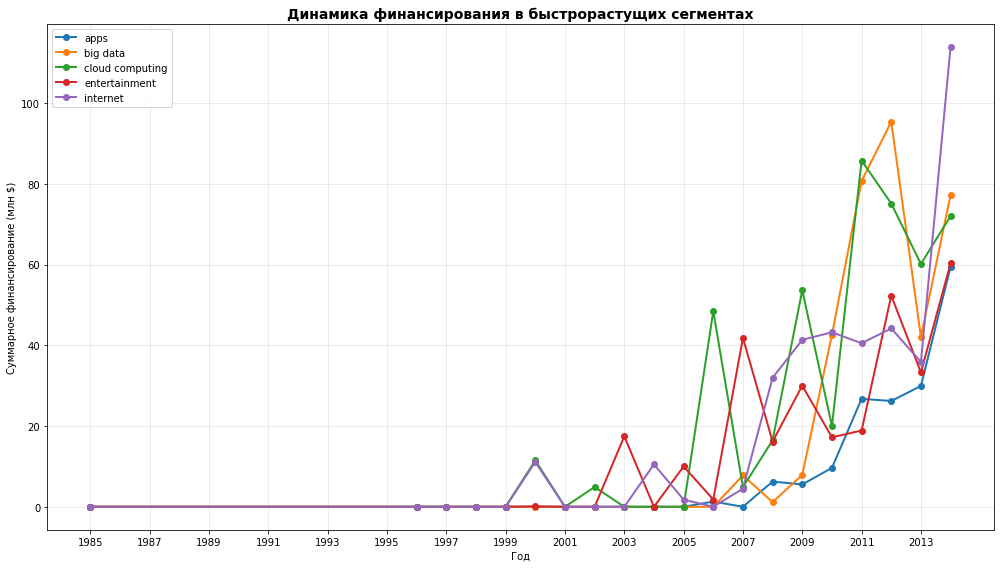

In [62]:
# График динамики финансирования по сегментам с ростом в 2014
import matplotlib.pyplot as plt

# Используем отобранные растущие сегменты
# Берём топ-5 для читаемости графика
top_growing = growing_segments[:5]

plt.figure(figsize=(14, 8))

for segment in top_growing:
    if segment in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[segment] / 1e6,
            "o-",
            linewidth=2,
            markersize=6,
            label=segment,
        )

plt.xlabel("Год")
plt.ylabel("Суммарное финансирование (млн $)")
plt.title(
    "Динамика финансирования в быстрорастущих сегментах", fontweight="bold", fontsize=14
)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

# Делаем подписи лет через каждые 2 года
plt.xticks(range(int(pivot.index.min()), int(pivot.index.max()) + 1, 2))

plt.tight_layout()
plt.show()

Вывод по динамике растущих сегментов:

На графике видно, что из отобранных сегментов наиболее быстрый и уверенный рост демонстрируют:

Cloud computing — стабильный восходящий тренд на протяжении всего периода, особенно активный рост в 2012–2014 годах.

Big data — уверенный рост с 2010 года, без сильных спадов, к 2014 году вышел на высокие значения.

Internet — показывает устойчивый рост, хотя и менее динамичный, чем лидеры.

Apps и Entertainment растут, но с большими колебаниями, уверенным их рост назвать сложно.

Итог: Самый перспективный сегмент — Cloud computing, на втором месте — Big data.

### 5.3. Доля возвращённых средств по типам финансирования

Для каждого года рассчитывается отношение возвращённых средств к объёму предоставленного финансирования. Экстремальные значения, возникающие при малом знаменателе или неполных данных, исключаются из интерпретации.

In [63]:
# Нормированные значения возврата средств по годам и типам финансирования

# 1. Суммы инвестиций по годам (из основного датасета)
investment_by_year = df_final.groupby("year")[
    ["seed", "venture", "angel", "debt_financing", "private_equity"]
].sum()

# 2. Суммы возвратов по годам (из cb_returns)
# Убедимся, что year - индекс
if "year" in cb_returns.columns:
    returns = cb_returns.set_index("year")
else:
    returns = cb_returns.copy()

# 3. Создаём таблицу для нормированных значений
norm_returns = pd.DataFrame(index=returns.index)

# 4. Считаем долю возврата для каждого типа
# Добавляем 1e-60 чтобы избежать деления на ноль
for col in ["seed", "venture", "angel", "debt_financing", "private_equity"]:
    if col in returns.columns and col in investment_by_year.columns:
        # Берём только общие годы
        common_years = returns.index.intersection(investment_by_year.index)

        # Расчёт доли: возвраты / инвестиции
        ratio = returns.loc[common_years, col] / (
            investment_by_year.loc[common_years, col] / 1e6 + 1e-60
        )

        # Заменяем аномальные значения (> 100% или < 0%) на NaN
        ratio = ratio.where((ratio <= 1) & (ratio >= 0))

        norm_returns[col] = ratio.round(4)

print("=== НОРМИРОВАННЫЕ ЗНАЧЕНИЯ ВОЗВРАТА (доля от инвестиций) ===")
print(norm_returns)

=== НОРМИРОВАННЫЕ ЗНАЧЕНИЯ ВОЗВРАТА (доля от инвестиций) ===
        seed  venture   angel  debt_financing  private_equity
year                                                         
2000  0.9191   0.1408  0.2503          0.7873          0.0000
2001  0.4131   0.1276     NaN          0.4989          0.0000
2002  0.5760   0.3280  0.8744          0.1486          0.0503
2003  0.3617   0.2823  0.5563          0.0693             NaN
2004  0.4469   0.3727  0.4778          0.1561             NaN
2005  0.4579   0.2425  0.4996          0.1561          0.0453
2006  0.6021   0.2646  0.5121          0.4361          0.2873
2007  0.3338   0.3145  0.7944          0.1574          0.4717
2008  0.2873   0.2305  0.4020          0.9229          0.6640
2009  0.4186   0.1480  0.5794          0.1719          0.2696
2010  0.4314   0.1792  0.5659          0.3070          0.4339
2011  0.2209   0.2611  0.4130          0.5422          0.3992
2012  0.1848   0.3826  0.5215          0.8269          0.9997
2013  0.1

Динамика нормированной возвратности рассматривается для `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

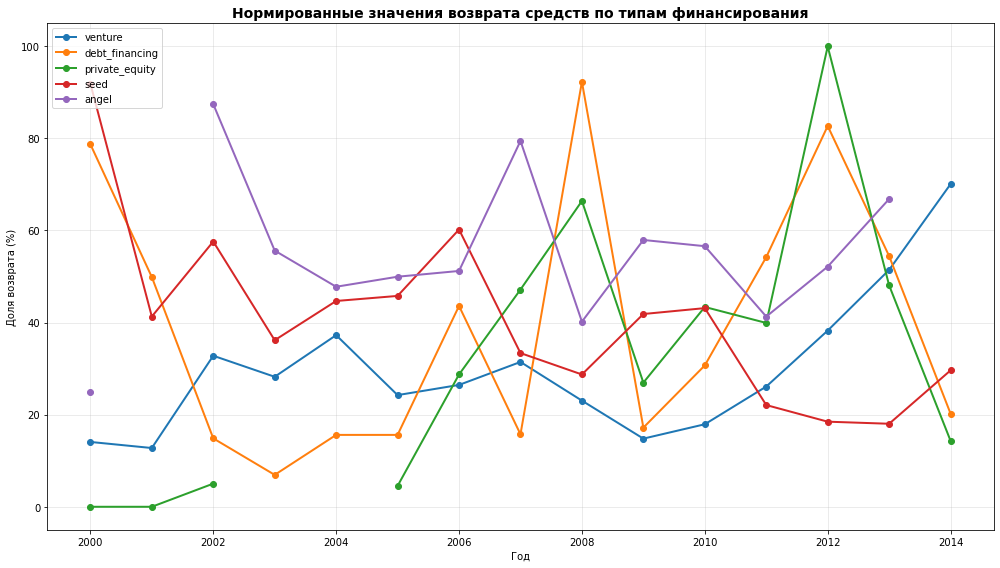

In [64]:
# Выбираем нужные типы финансирования
types_to_plot = ["venture", "debt_financing", "private_equity", "seed", "angel"]

plt.figure(figsize=(14, 8))

for funding_type in types_to_plot:
    if funding_type in norm_returns.columns:
        plt.plot(
            norm_returns.index,
            norm_returns[funding_type] * 100,
            "o-",
            linewidth=2,
            markersize=6,
            label=funding_type,
        )

plt.xlabel("Год")
plt.ylabel("Доля возврата (%)")
plt.title(
    "Нормированные значения возврата средств по типам финансирования",
    fontweight="bold",
    fontsize=14,
)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

# Делаем подписи лет через каждые 2 года
plt.xticks(range(int(norm_returns.index.min()), int(norm_returns.index.max()) + 1, 2))

plt.tight_layout()
plt.show()

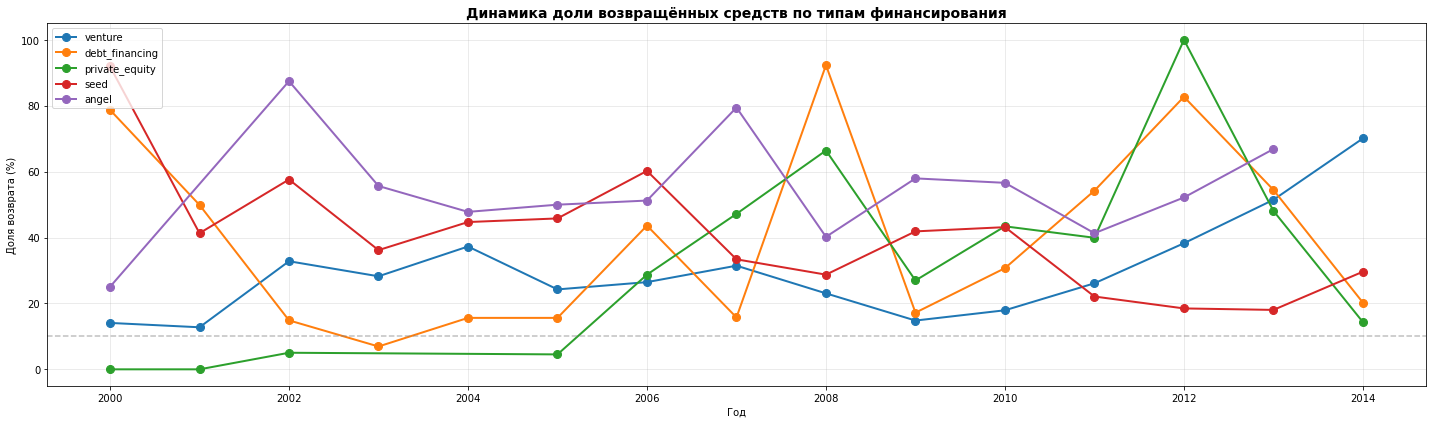

In [65]:
# График нормированных значений возврата средств
# Выбираем нужные типы финансирования
types_to_plot = ["venture", "debt_financing", "private_equity", "seed", "angel"]

plt.figure(figsize=(20, 6))

for funding_type in types_to_plot:
    if funding_type in norm_returns.columns:
        # Убираем пропуски для построения линии
        data = norm_returns[funding_type].dropna()
        if len(data) > 0:
            plt.plot(
                data.index,
                data.values * 100,
                "o-",
                linewidth=2,
                markersize=8,
                label=funding_type,
            )

plt.xlabel("Год")
plt.ylabel("Доля возврата (%)")
plt.title(
    "Динамика доли возвращённых средств по типам финансирования",
    fontweight="bold",
    fontsize=14,
)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

# Делаем подписи лет через каждые 2 года
plt.xticks(range(int(norm_returns.index.min()), int(norm_returns.index.max()) + 1, 2))

# Добавляем горизонтальную линию на уровне 10% для ориентира
plt.axhline(y=10, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Вывод по динамике доли возвращённых средств

| Тип финансирования | Динамика | Ключевые наблюдения |
|-------------------|----------|---------------------|
| **Venture** | 📈 Устойчивый рост | С 14% (2000) до **70% (2014)**. Самый быстрорастущий тип, максимум в 2014 году. |
| **Private equity** | 📉 Нестабильный | Пик 99.9% (2012), но к 2014 падение до 14%. Сильные колебания. |
| **Debt financing** | 📊 Всплесками | Максимумы в 2008 (92%) и 2012 (83%). В 2014 снижение до 20%. |
| **Angel** | 📈 Относительно стабильный | Диапазон 40–80%. Пик 67% (2013), в 2014 данных нет. |
| **Seed** | 📉 Устойчивое падение | С 92% (2000) до 18–30% (2012–2014). Тренд на снижение. |

---

**Итоговые выводы:**

1. **Venture** — единственный тип, показывающий **уверенный и устойчивый рост** на протяжении всего периода. К 2014 году доля возврата достигла **70%** — максимальное значение среди всех типов.

2. **Private equity** и **debt financing** демонстрируют **высокие пики**, но их динамика **нестабильна**, что делает их рискованными для долгосрочных прогнозов.

3. **Seed** — **стабильно падает**, несмотря на высокие показатели в начале 2000-х. К 2014 году доля возврата минимальна.

4. **Angel** держится на **среднем уровне** (40–80%), но отсутствие данных за 2014 год не позволяет оценить текущую динамику.

**Рекомендация:** Наиболее привлекательным типом финансирования с точки зрения возвратности выглядит **venture** — он сочетает высокие показатели с устойчивым ростом.

## 6. Итоговые выводы и инвестиционная рекомендация

### Рекомендация на 2015 год

Наиболее обоснованным направлением выглядит инвестиция в сегмент **Software** с использованием **венчурного финансирования**.

Software лидирует по совокупному объёму капитала и сохраняет высокую инвестиционную активность. Смежные направления Cloud computing и Big data демонстрируют уверенный рост, что усиливает привлекательность технологического сектора. Венчурное финансирование доминирует по объёму и частоте использования и показывает наиболее устойчивую положительную динамику нормированной возвратности среди рассмотренных инструментов.

### Ключевые результаты

Компании с длительностью финансирования более года составляют меньшую часть рынка, но привлекают основную долю капитала. Распределение финансирования сильно скошено вправо: небольшое число компаний получает несопоставимо крупные суммы.

Инвестиционная активность росла до 2013 года, после чего в 2014 году наблюдалось умеренное снижение числа раундов. При этом технологические сегменты, включая Cloud computing и Big data, сохранили положительную динамику.

### Ограничения

Данные за ранние годы представлены меньшим числом наблюдений, часть справочных признаков заполнена не полностью, а результаты за 2014 год могут отражать неполный календарный период. Поэтому рекомендация относится к структуре доступной исторической выборки и требует дополнительной проверки на более свежих данных и финансовых показателях конкретных компаний.